In [2]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
import matplotlib as mpl
from helpers.simulation import *
from helpers.qtransform import *
from helpers.config import *

from scipy.stats import truncnorm
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/gwaves_lisa_py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [11]:
mixed_dict = {}
with h5py.File(training_ehm_dataset_path, 'r+') as h5:
    for key in list(h5.keys()):
        mixed_dict[key] = h5[key][:]

In [52]:
with h5py.File(mixed_ehm_dataset_path, 'r+') as h5:
    t_axes = h5['t_qscan'][:]
    f_axes = h5['f_qscan'][:]
    seps = h5['sep'][:]

In [15]:
idx = np.where(np.all(mixed_dict['labels'] == [1, 1], axis=1))[0]
images = mixed_dict['images'][idx]
labels = mixed_dict['labels'][idx]
sim_idx = mixed_dict['sim_index'][idx]
time_idx = mixed_dict['time_index'][idx]

In [53]:
index = 100

image = images[index, :, :, 0]
t_axis = t_axes[sim_idx[index], time_idx[index], :]
f_axis = f_axes[sim_idx[index], time_idx[index], :]
sep = seps[sim_idx[index]]

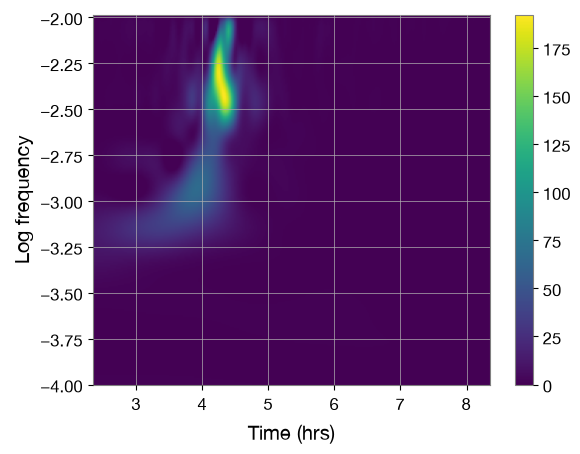

-0.7837718


In [39]:
plt.imshow(image, extent=[t_axis[0]/3600, t_axis[-1]/3600, np.log10(f_axis[0]), np.log10(f_axis[-1])],\
     aspect='auto', origin='lower')
#plt.title(f'Amp = {amp:.2g} m/s^2, Beta = {beta:.2g} secs,\n Inj_point: {inj_point}, t_inj: {tevent/3600} hrs', fontsize=12)
plt.colorbar()

#plt.clim(0, 5)
plt.ylabel('Log frequency')
plt.xlabel('Time (hrs)')
plt.show()
print(sep)

In [40]:
F_grid, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

threshold = 8
snr = np.sqrt(image**2 - 1)
mask = (snr > threshold)

F_opt = F_grid[mask]
T_opt = T_grid[mask]/3600

In [41]:
times = np.linspace(t_axis[0]/3600, t_axis[-1]/3600, 1000)
pdf = gaussian_kde(T_opt)(times)

peaks, props = find_peaks(pdf, width=1, prominence=0.05)
found = times[peaks]
true = np.array([5-sep, 5+sep])

In [42]:
count = 0
for time in found:
    if np.min(np.abs(found - time)) < 0.5:
        count += 1

print(count)

1


In [59]:
threshold = 8
counts = []
good_idx, bad_idx = [], []
for index in range(images.shape[0]):
    image = images[index, :, :, 0]
    t_axis = t_axes[sim_idx[index], time_idx[index], :]
    f_axis = f_axes[sim_idx[index], time_idx[index], :]
    sep = seps[sim_idx[index]]

    F_grid, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

    snr = np.sqrt(image**2 - 1)
    mask = (snr > threshold)

    T_opt = T_grid[mask]/3600
    try:
        times = np.linspace(t_axis[0]/3600, t_axis[-1]/3600, 1000)
        pdf = gaussian_kde(T_opt)(times)

        peaks, props = find_peaks(pdf, width=1, prominence=0.05)
        found = times[peaks]
        true = np.array([5-sep, 5+sep])

        count = 0
        for time in found:
            if np.min(np.abs(found - time)) < 0.5:
                count += 1
        
        if count < 2:
            bad_idx.append(index)
        elif count == 2:
            good_idx.append(index)

    except:
        count = 0
    counts.append(count)
    #if index%50 == 0:
     #   print(f'Image {index} out of {images.shape[0]} done')

counts = np.array(counts)
good_idx = np.array(good_idx)
bad_idx = np.array(bad_idx)

## On mixed datasets

In [12]:
mixed_dict = {}
#keys = ['QT', 't_qscan', 'f_qscan', 'tcen', 'sep']
with h5py.File(mixed_ehm_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        mixed_dict[key] = h5[key][:]

In [13]:
threshold = 8
gw_found, glitch_found, both_found, none_found = [],[],[],[]
for i in range(mixed_dict['QT'].shape[0]):
    idx = np.argmin(np.abs(mixed_dict['tcen'][i]))
    image = mixed_dict['QT'][i, idx, :, :, 0]
    t_axis = mixed_dict['t_qscan'][i, idx, :]
    f_axis = mixed_dict['f_qscan'][i, idx, :]
    sep = mixed_dict['sep'][i]

    F_grid, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

    snr = np.sqrt(image**2 - 1)
    mask = (snr > threshold)

    F_opt = F_grid[mask]
    T_opt = T_grid[mask]/3600

    try:
        times = np.linspace(t_axis[0]/3600, t_axis[-1]/3600, 1000)
        pdf = gaussian_kde(T_opt)(times)

        peaks, props = find_peaks(pdf, width=1, prominence=0.05)
        found = times[peaks]

        if len(found[found < 5]) > 0 and len(found[found > 5]) > 0:
            both_found.append(i)
        elif len(found) == 0:
            none_found.append(i)
        elif sep >= 0:
            if len(found[found < 5]) > 0:
                glitch_found.append(i)
            elif len(found[found > 5]) > 0:
                gw_found.append(i)
        elif sep < 0:
            if len(found[found > 5]) > 0:
                glitch_found.append(i)
            elif len(found[found < 5]) > 0:
                gw_found.append(i)

    except:
        none_found.append(i)

gw_found = np.array(gw_found)
glitch_found = np.array(glitch_found)
both_found = np.array(both_found)
none_found = np.array(none_found)

KeyError: 'QT'

In [161]:
len(gw_found), len(glitch_found), len(both_found), len(none_found)

(39, 8, 203, 0)

In [172]:
both_found[:50]

array([ 1,  2,  3,  4,  5,  6,  7,  9, 10, 11, 12, 14, 15, 16,
       17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 31, 32, 34, 35,
       36, 37, 38, 40, 41, 42, 43, 44, 48, 49, 51, 52, 54, 55,
       56, 57, 58, 59, 60, 62, 63, 64])

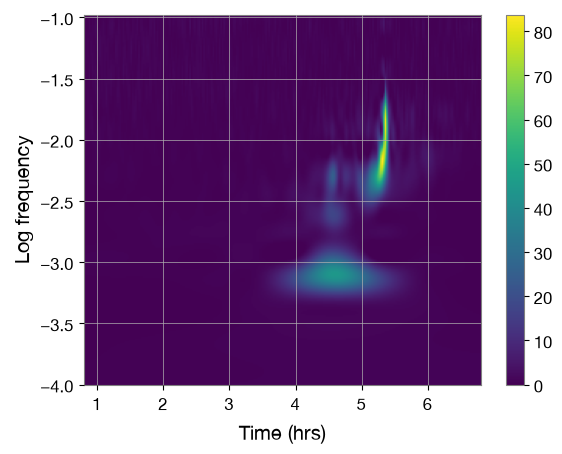

In [181]:
i = 42
idx = np.argmin(np.abs(mixed_dict['tcen'][i]))
idx = 4
image = mixed_dict['QT'][i, idx, :, :, 0]
t_axis = mixed_dict['t_qscan'][i, idx, :]
f_axis = mixed_dict['f_qscan'][i, idx, :]

plt.imshow(image, extent=[t_axis[0]/3600, t_axis[-1]/3600, np.log10(f_axis[0]), np.log10(f_axis[-1])],\
     aspect='auto', origin='lower')
#plt.title(f'Amp = {amp:.2g} m/s^2, Beta = {beta:.2g} secs,\n Inj_point: {inj_point}, t_inj: {tevent/3600} hrs', fontsize=12)
plt.colorbar()

#plt.clim(0, 10)
plt.ylabel('Log frequency')
plt.xlabel('Time (hrs)')
plt.show()

In [163]:
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u

indices = both_found

m1_arr = mixed_dict['m1'][indices]
m2_arr = mixed_dict['m2'][indices]
d_arr = mixed_dict['d'][indices]
z_arr = z_at_value(Planck18.luminosity_distance, d_arr*u.Mpc)
sep_arr = mixed_dict['sep'][indices]

In [164]:
bins = np.arange(-3, 3, 0.25)
counts1, bin_edges1 = np.histogram(2*mixed_dict['sep'], bins=bins)
counts2, bin_edges2 = np.histogram(2*sep_arr, bins=bins)

bins = 0.5 * (bin_edges1[:-1] + bin_edges1[1:])

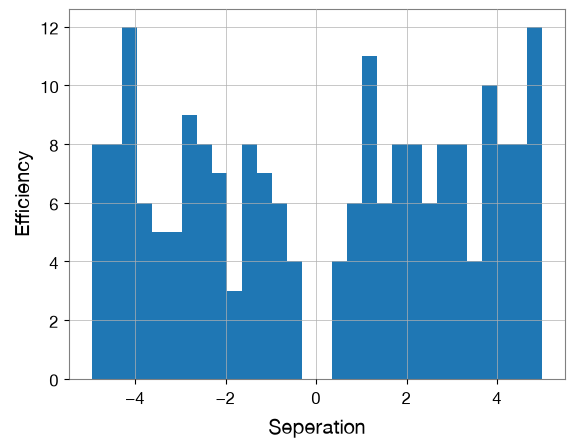

In [167]:
plt.hist(2*sep_arr, bins=30)
plt.xlabel('Seperation')
plt.ylabel('Efficiency')
plt.show()

In [71]:
print(mixed_dict.keys())

dict_keys(['QT', 'X', 'Y', 'Z', 'amp', 'beta', 'd', 'f_qscan', 'gw_beta', 'gw_lambda', 'inj_point', 'iota', 'm1', 'm2', 'sep', 'spin1', 'spin2', 't0', 't_qscan', 'tcen'])


In [168]:
good_idx = both_found
bad_idx = np.concatenate([gw_found, glitch_found, none_found]).astype(int)
bad_idx = gw_found

amp_arr1 = mixed_dict['amp'][good_idx]
beta_arr1 = mixed_dict['beta'][good_idx]

amp_arr2 = mixed_dict['amp'][bad_idx]
beta_arr2 = mixed_dict['beta'][bad_idx]

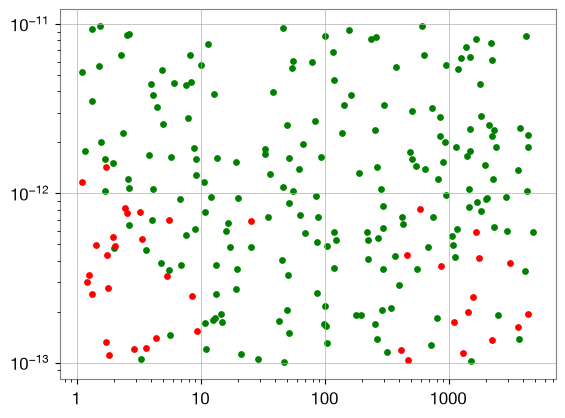

In [169]:
plt.scatter(beta_arr1, amp_arr1, s=15, color='green')
plt.scatter(beta_arr2, amp_arr2, s=15, color='red')
plt.xscale('log')
plt.yscale('log')
plt.show()

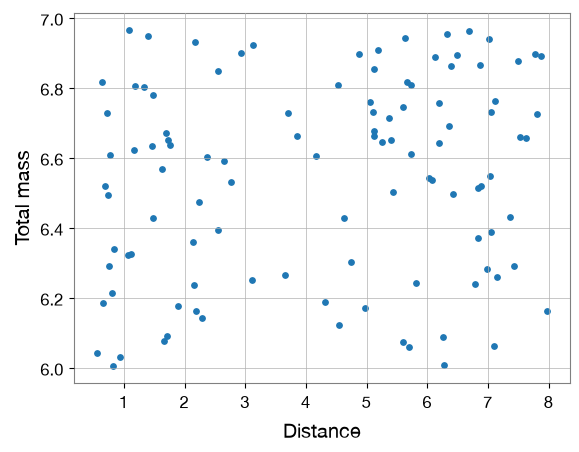

In [68]:
plt.scatter(z_arr, np.log10(m1_arr+m2_arr), s=15)
plt.xlabel('Distance')
plt.ylabel('Total mass')
plt.show()

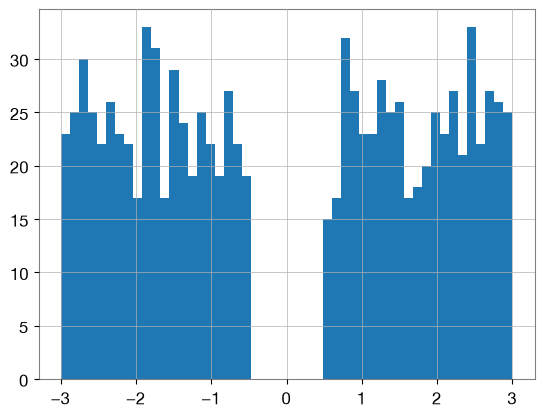

In [114]:
seps_try = np.random.choice([-1, 1], size=1000)*np.random.uniform(0.25, 1.5, size=1000)

plt.hist(2*seps_try, bins=50)
plt.show()

(array([ 1.,  1.,  4.,  5.,  3.,  0.,  4.,  2.,  5.,  2.,  2.,
         4.,  4.,  5.,  3., 11.,  5.,  9.,  6.,  9.,  5., 10.,
         9., 10.,  8., 20., 20., 22., 30., 31.]),
 array([3.51299858, 3.55969334, 3.60638785, 3.65308261,
        3.69977736, 3.74647188, 3.79316664, 3.83986139,
        3.88655591, 3.93325067, 3.97994542, 4.02663994,
        4.07333469, 4.12002945, 4.16672421, 4.21341896,
        4.26011324, 4.30680799, 4.35350275, 4.40019751,
        4.44689226, 4.49358654, 4.5402813 , 4.58697605,
        4.63367081, 4.68036556, 4.72706032, 4.77375507,
        4.82044983, 4.86714411, 4.91383886]),
 <BarContainer object of 30 artists>)

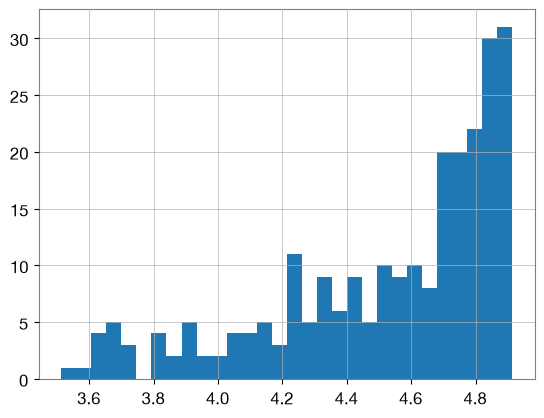

In [183]:
plt.hist(np.log10(mixed_dict['d']), bins=30)

## On GW datasets

In [3]:
gw_dict = {}
#keys = ['QT', 't_qscan', 'f_qscan', 'tcen', 'sep']
with h5py.File(glitch_ehm_dataset_path, 'r') as h5:
    for key in list(h5.keys()):
        gw_dict[key] = h5[key][:]

In [8]:
threshold = 8
gw_found, none_found = [],[]
for i in range(gw_dict['QT'].shape[0]):
    idx = np.argmin(np.abs(gw_dict['tcen'][i]))
    image = gw_dict['QT'][i, idx, :, :, 0]
    t_axis = gw_dict['t_qscan'][i, idx, :]
    f_axis = gw_dict['f_qscan'][i, idx, :]

    F_grid, T_grid = np.meshgrid(f_axis, t_axis, indexing="ij")

    snr = np.sqrt(image**2 - 1)
    mask = (snr > threshold)

    F_opt = F_grid[mask]
    T_opt = T_grid[mask]/3600

    try:
        times = np.linspace(t_axis[0]/3600, t_axis[-1]/3600, 1000)
        pdf = gaussian_kde(T_opt)(times)

        peaks, props = find_peaks(pdf, width=1, prominence=0.05)
        found = times[peaks]

        if len(found) > 0:
            gw_found.append(i)
        elif len(found) == 0:
            none_found.append(i)

    except:
        none_found.append(i)

gw_found = np.array(gw_found)
none_found = np.array(none_found)

In [9]:
len(gw_found), len(none_found)

(790, 210)

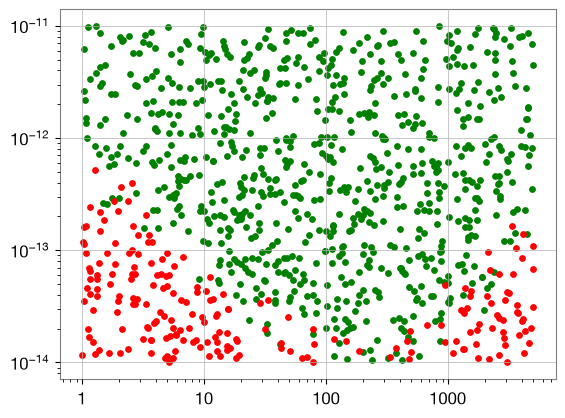

In [10]:
amp_arr1 = gw_dict['amp'][gw_found]
beta_arr1 = gw_dict['beta'][gw_found]

amp_arr2 = gw_dict['amp'][none_found]
beta_arr2 = gw_dict['beta'][none_found]

plt.scatter(beta_arr1, amp_arr1, s=15, color='green')
plt.scatter(beta_arr2, amp_arr2, s=15, color='red')
plt.xscale('log')
plt.yscale('log')
plt.show()